## Nome: Pedro Henrique de Paiva Carvalho
## Matrícula: 2162

---

# Atividade 8 - Ajuste de Curvas Não Polinomial (Ajuste Não Linear)

### Funções de Ajuste Não Polinomial

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Modelo: Decaimento Exponencial Amortecido com Termo Senoidal Amortecido
def modelo_nao_linear(t, T_amb, A, a, B, b, w):
    return T_amb + A * np.exp(-a * t) + B * np.exp(-b * t) * np.cos(w * t)

In [ ]:
def plot_ajuste_nao_linear(ts, ys, popt, pontos_estimativa=None):
    """
    Plota a curva ajustada não linear a partir dos parâmetros otimizados.

    Parâmetros:
    -----------
    ts : array-like
        Pontos de medição de tempo.
    ys : array-like
        Valores medidos (ex: temperatura).
    popt : lista ou array
        Parâmetros otimizados obtidos pela curve_fit.
    pontos_estimativa : lista ou array, opcional
        Instantes de tempo para destacar estimativas no gráfico.
    """
    # Eixo denso para plotagem contínua da curva ajustada
    tt = np.linspace(min(ts), max(ts) + 2, 800)
    y_fit = modelo_nao_linear(tt, *popt)

    plt.figure(figsize=(9, 5))

    # Plota os dados reais experimentais
    plt.scatter(ts, ys, label='Dados Experimentais', color='blue', zorder=5)

    # Plota o modelo ajustado
    plt.plot(tt, y_fit, label='Ajuste Não Polinomial (Modelo Complexo)', color='darkred', linewidth=2)

    # Marca pontos de estimativa caso fornecidos
    if pontos_estimativa is not None:
        pontos_estimativa = np.array(pontos_estimativa)
        y_est = modelo_nao_linear(pontos_estimativa, *popt)
        plt.scatter(pontos_estimativa, y_est, marker='x', s=90, color='green', label='Estimativas', zorder=6)

    plt.xlabel('Tempo (min)')
    plt.ylabel('Temperatura (°C)')
    plt.title('Ajuste Não Polinomial — Dinâmica Térmica Amortecida')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


def ajustar_modelo(t, y, params0, max_iter=200, tol=1e-8):
    """
    Ajusta o modelo não linear aos dados (t, y) pelo método de Gauss-Newton,
    partindo da estimativa inicial params0.

    Parâmetros:
    -----------
    t : array-like
        Pontos de tempo medidos.
    y : array-like
        Valores medidos (temperatura).
    params0 : array-like
        Estimativa inicial dos parâmetros (T_amb, A, a, B, b, w).
    max_iter : int
        Número máximo de iterações.
    tol : float
        Critério de parada (norma do passo de atualização).

    Retorna:
    --------
    popt : array
        Parâmetros otimizados (T_amb, A, a, B, b, w).
    """
    def residuo(params):
        return modelo_nao_linear(t, *params) - y

    def jacobiano_numerico(params, eps=1e-6):
        n = len(params)
        r0 = residuo(params)
        J = np.zeros((len(t), n))
        for j in range(n):
            p_perturbado = params.copy()
            p_perturbado[j] += eps
            J[:, j] = (residuo(p_perturbado) - r0) / eps
        return J, r0

    params = np.array(params0, dtype=float)
    for _ in range(max_iter):
        J, r = jacobiano_numerico(params)
        JTJ = J.T @ J
        JTr = J.T @ r
        delta = np.linalg.solve(JTJ, -JTr)

        alpha = 1.0
        erro_atual = np.sum(r**2)
        while True:
            novo_params = params + alpha * delta
            novo_erro = np.sum(residuo(novo_params)**2)
            if novo_erro < erro_atual or alpha < 1e-8:
                break
            alpha /= 2

        params = novo_params
        if np.linalg.norm(alpha * delta) < tol:
            break

    return params # Saídas: T_amb, A, a, B, b, w

### Parte Prática

Uma equipe de engenharia química e de materiais está monitorando a reação exotérmica amortecida dentro de um reator durante o resfriamento sob convecção forçada e trocas térmicas oscilatórias. Devido à complexidade do fenômeno, o comportamento da temperatura em função do tempo não segue um polinômio simples, necessitando de um modelo não linear ajustado ("função cabeluda") do tipo:

$$T(t) = T_{amb} + A \cdot e^{-a \cdot t} + B \cdot e^{-b \cdot t} \cdot \cos(w \cdot t)$$

Os dados coletados pelo sistema SCADA estão descritos na tabela abaixo:

| Tempo (min) | Temperatura (°C) |
|---|---|
| 0.0 | 820.0 |
| 0.5 | 695.5 |
| 1.0 | 580.2 |
| 2.0 | 415.0 |
| 3.0 | 310.8 |
| 4.0 | 240.3 |
| 5.0 | 192.1 |
| 7.0 | 135.4 |
| 9.0 | 102.7 |
| 12.0 | 75.0 |

Com base nesses dados, responda:

1. Utilize a função `ajustar_modelo` Estimativas iniciais $p_0 = [25, 600, 0.2, 200, 0.1, 1.5]$ para determinar os coeficientes otimizados do modelo. Em seguida, estime a temperatura nos instantes $t = 1.5\text{ min}$, $t = 6.0\text{ min}$ e $t = 10.0\text{ min}$ (arredonde para duas casas decimais).

In [ ]:
t_dados = np.array([0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 7.0, 9.0, 12.0])
y_dados = np.array([820.0, 695.5, 580.2, 415.0, 310.8, 240.3, 192.1, 135.4, 102.7, 75.0])


p0 = [25, 600, 0.2, 200, 0.1, 1.5]

popt = ajustar_modelo(t_dados, y_dados, p0)


# Estimando a temperatura para t = 1.5, 6.0 e 10.0
pontos_estimativa = [1.5, 6.0, 10.0]
y_estimados = modelo_nao_linear(np.array(pontos_estimativa), *popt)

print("Estimativas de Temperatura:")
for t_val, y_val in zip(pontos_estimativa, y_estimados):
    print(f"t = {t_val:.1f} min -> T = {y_val:.2f} °C")

Estimativas de Temperatura:
t = 1.5 min -> T = 490.61 °C
t = 6.0 min -> T = 160.55 °C
t = 10.0 min -> T = 90.34 °C


2. Plote um gráfico contendo os pontos medidos, a curva ajustada do modelo não linear e os pontos estimados destacando os valores previstos.

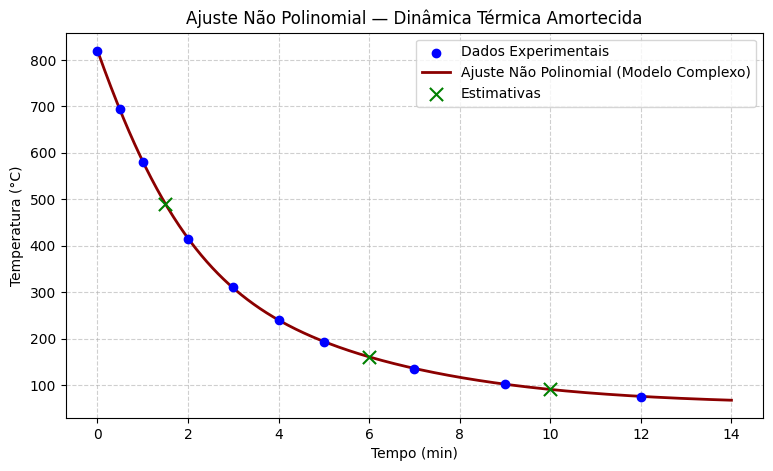

In [ ]:
# Plotando o gráfico utilizando a função auxiliar já fornecida no início do notebook
plot_ajuste_nao_linear(t_dados, y_dados, popt, pontos_estimativa=pontos_estimativa)

### Parte Teórica

1. Por que em problemas físicos/químicos complexos prefere-se utilizar um modelo de ajuste baseado em funções fundamentais (ex: exponenciais e senoidais) em vez de ajustar um polinômio de alto grau (ex: de grau 8 ou 9)?

Resposta: Usamos modelos fundamentais (como exponenciais) porque eles refletem a física real do problema e permitem extrapolar dados com segurança. Polinômios de grau alto oscilam demais e geram erros absurdos se tentarmos prever valores fora do intervalo medido.

2. Diferencie o conceito de **Interpolação** (como o Polinômio de Lagrange) do conceito de **Ajuste de Curvas por Mínimos Quadrados** (Regressão). Em que situação com dados ruidosos de sensores um método deve ser escolhido em detrimento do outro?

Resposta: A interpolação obriga a curva a passar exatamente por todos os pontos, enquanto o ajuste traça uma curva média para minimizar os erros. Para sensores ruidosos, usamos o ajuste de curvas: ele mostra a tendência real e ignora as falhas pontuais de leitura.

3. Dado um mesmo conjunto de dados, é possível obter parâmetros otimizados diferentes dependendo da estimativa inicial p0 escolhida. Explique por que isso acontece em problemas de ajuste não linear e qual o risco de escolher uma estimativa inicial muito distante dos valores reais.

Resposta: Os cálculos não lineares funcionam por tentativas iterativas. Se você começar com uma estimativa inicial muito ruim, o algoritmo se "perde" (cai num mínimo local errado ou diverge), gerando uma curva sem nenhum sentido prático.